In [1]:
# ============================================
# WOMEN'S MENTAL HEALTH PROJECT
# Notebook 2: Exploratory Data Analysis
# Author: Christelle Denny
# Date: June 2026
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load master dataset
master = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Women's Mental Health/Clean Data/master_dataset.csv")

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded!")
print("✓ Master dataset loaded!")
print(f"Shape: {master.shape}")
print(f"\nColumns: {list(master.columns)}")
print(f"\nPreview:")
print(master.head(3))

✓ Libraries loaded!
✓ Master dataset loaded!
Shape: (1050, 9)

Columns: ['country', 'year', 'depression_rate', 'anxiety_rate', 'Region', 'Income group', 'gii_score', 'gdp_per_capita', 'psychiatrists_per_100k']

Preview:
     country  year  depression_rate  anxiety_rate                      Region  \
0   Suriname  2000      5075.188955   6919.581675   Latin America & Caribbean   
1  Guatemala  2000      5421.266100   5772.134496   Latin America & Caribbean   
2    Algeria  2000      5722.728997   7536.216001  Middle East & North Africa   

          Income group  gii_score  gdp_per_capita  psychiatrists_per_100k  
0  Upper middle income      0.421     1988.221729                     2.0  
1  Upper middle income      0.584     1648.965790                     0.0  
2  Upper middle income      0.610     1772.928691                     2.0  


In [2]:
# ============================================
# STEP 1: BASIC STATISTICS
# ============================================

print("=== DEPRESSION RATE ===")
print(master['depression_rate'].describe())

print("\n=== ANXIETY RATE ===")
print(master['anxiety_rate'].describe())

print("\n=== GII SCORE ===")
print(master['gii_score'].describe())

print("\n=== GDP PER CAPITA ===")
print(master['gdp_per_capita'].describe())

print("\n=== PSYCHIATRISTS PER 100K ===")
print(master['psychiatrists_per_100k'].describe())

=== DEPRESSION RATE ===
count     1050.000000
mean      5025.834731
std       1434.067903
min       2047.983794
25%       4078.324894
50%       4914.627011
75%       5778.252001
max      12268.429146
Name: depression_rate, dtype: float64

=== ANXIETY RATE ===
count     1050.000000
mean      6611.528904
std       2824.040702
min       1537.016938
25%       4298.672184
50%       6361.735641
75%       8353.477929
max      17653.083473
Name: anxiety_rate, dtype: float64

=== GII SCORE ===
count    1050.000000
mean        0.365586
std         0.200066
min         0.008000
25%         0.190000
50%         0.381500
75%         0.525750
max         0.816000
Name: gii_score, dtype: float64

=== GDP PER CAPITA ===
count      1050.000000
mean      13151.175454
std       18973.545880
min         122.269203
25%        1452.159426
50%        4799.056133
75%       16341.906299
max      134965.815442
Name: gdp_per_capita, dtype: float64

=== PSYCHIATRISTS PER 100K ===
count    1050.000000
mean        

In [3]:
# ============================================
# STEP 2: INCOME GROUP COUNTS
# ============================================

print("=== COUNTRIES BY INCOME GROUP ===")
print(master.groupby('Income group')['country'].nunique())

print("\n=== REGIONS IN DATASET ===")
print(master.groupby('Region')['country'].nunique())

=== COUNTRIES BY INCOME GROUP ===
Income group
High income            51
Low income             18
Lower middle income    38
Upper middle income    43
Name: country, dtype: int64

=== REGIONS IN DATASET ===
Region
East Asia & Pacific           20
Europe & Central Asia         43
Latin America & Caribbean     26
Middle East & North Africa    17
North America                  1
South Asia                     8
Sub-Saharan Africa            35
Name: country, dtype: int64


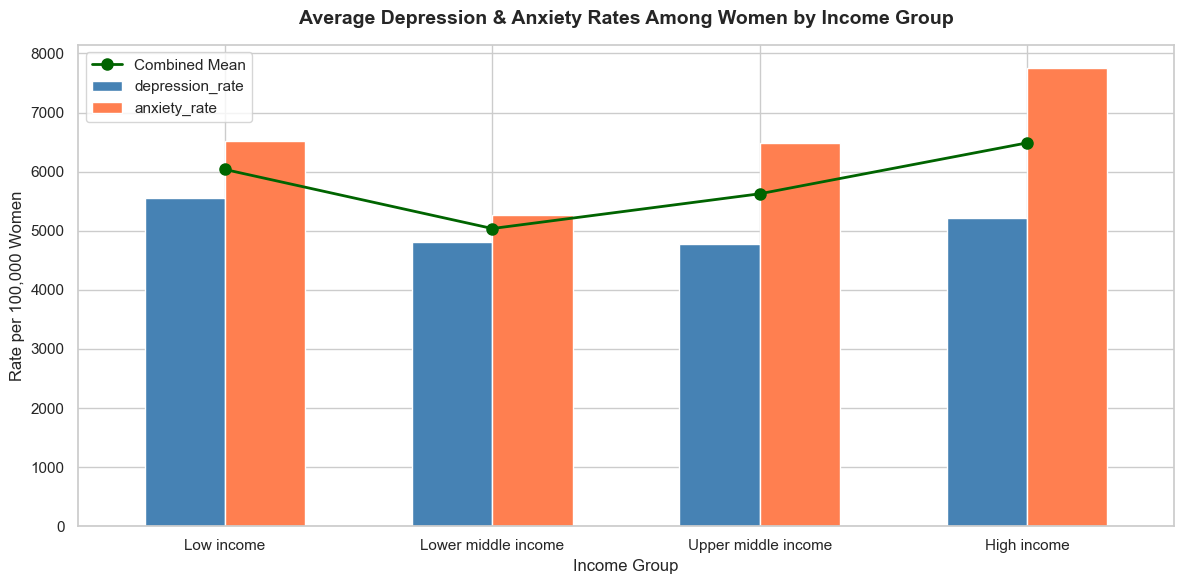

✓ Chart saved!


In [15]:
# ============================================
# STEP 3: DEPRESSION & ANXIETY BY INCOME GROUP
# ============================================

# Calculate averages by income group
income_stats = master.groupby('Income group')[['depression_rate', 'anxiety_rate']].mean()

# Define custom order — low to high income
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
# Reindex to apply order
income_stats = income_stats.reindex(income_order)

# Calculate combined mean per income group
income_stats['combined_mean'] = (income_stats['depression_rate'] + income_stats['anxiety_rate']) / 2

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

income_stats[['depression_rate', 'anxiety_rate']].plot(
    kind='bar',
    ax=ax,
    color=['steelblue', 'coral'],
    width=0.6,
    edgecolor='white'
)

# Add combined mean line per income group
ax.plot(range(len(income_stats)), income_stats['combined_mean'],
        color='darkgreen', marker='o', linewidth=2,
        markersize=8, label='Combined Mean', zorder=5)

ax.set_title('Average Depression & Anxiety Rates Among Women by Income Group',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Income Group', fontsize=12)
ax.set_ylabel('Rate per 100,000 Women', fontsize=12)
ax.set_xticklabels(income_stats.index, rotation=0, ha='center')
ax.legend()

plt.tight_layout()
plt.savefig("C:/Users/Dell/OneDrive/Desktop/Women's Mental Health/Visualizations/01_rates_by_income_group.png", dpi=150)
plt.show()
print("✓ Chart saved!")

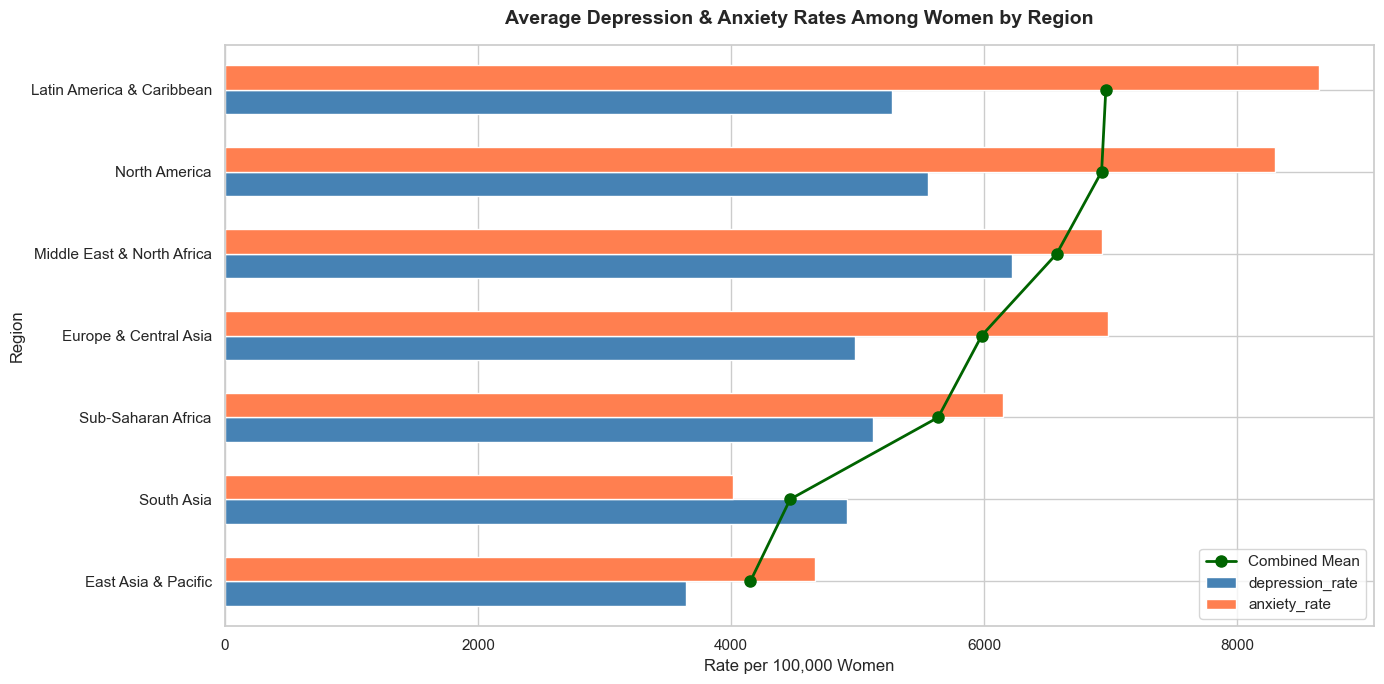

✓ Chart saved!


In [16]:
# ============================================
# STEP 4: DEPRESSION & ANXIETY BY REGION
# ============================================

# Calculate averages by region
region_stats = master.groupby('Region')[['depression_rate', 'anxiety_rate']].mean()

# Calculate combined mean per region
region_stats['combined_mean'] = (region_stats['depression_rate'] + region_stats['anxiety_rate']) / 2

# Sort by combined mean
region_stats = region_stats.sort_values('combined_mean', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

region_stats[['depression_rate', 'anxiety_rate']].plot(
    kind='barh',
    ax=ax,
    color=['steelblue', 'coral'],
    width=0.6,
    edgecolor='white'
)

# Add combined mean line
ax.plot(region_stats['combined_mean'], range(len(region_stats)),
        color='darkgreen', marker='o', linewidth=2,
        markersize=8, label='Combined Mean', zorder=5)

ax.set_title('Average Depression & Anxiety Rates Among Women by Region',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rate per 100,000 Women', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig("C:/Users/Dell/OneDrive/Desktop/Women's Mental Health/Visualizations/02_rates_by_region.png", dpi=150)
plt.show()
print("✓ Chart saved!")

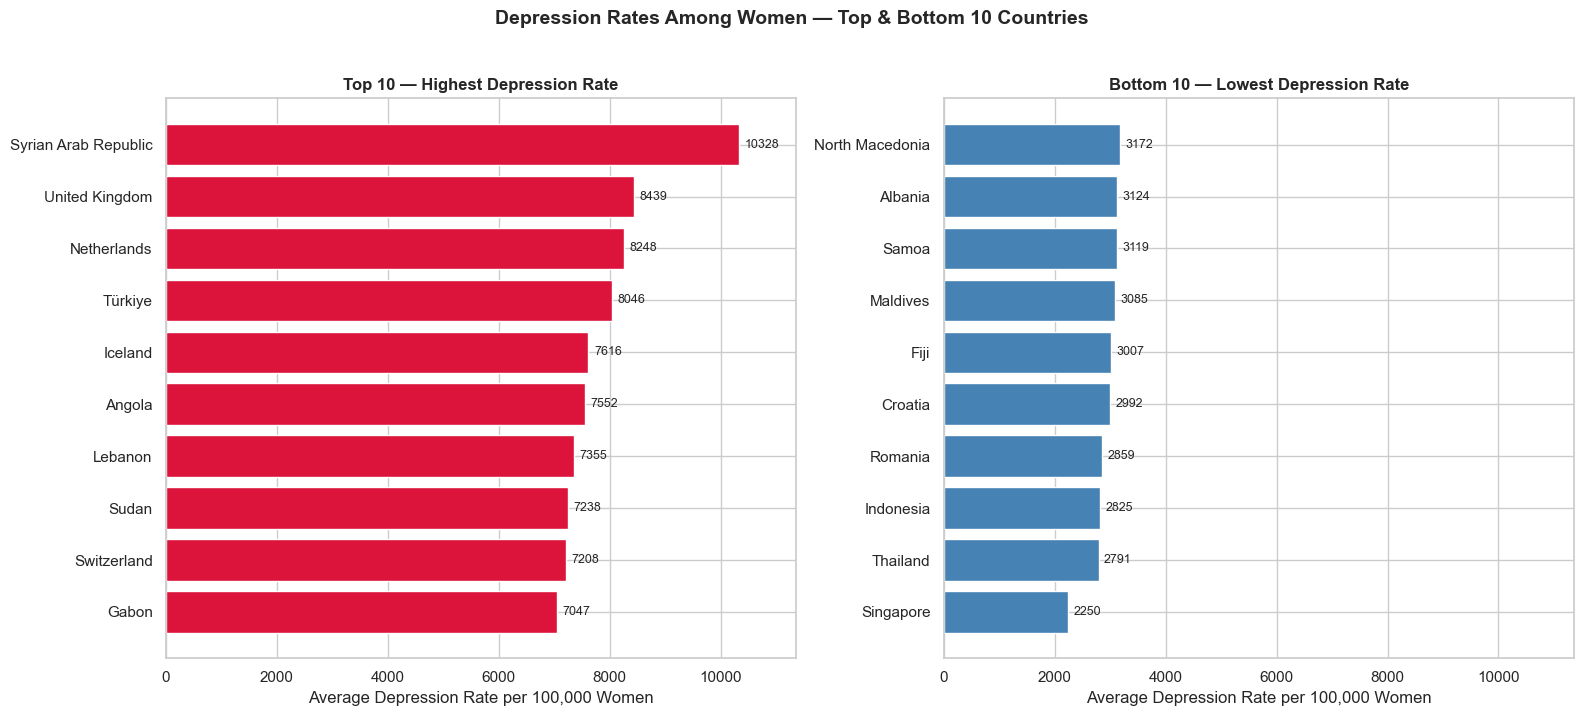

✓ Chart saved!


In [18]:
# ============================================
# STEP 5: TOP 10 & BOTTOM 10 COUNTRIES
# ============================================

# Get average depression rate per country across all years
country_avg = master.groupby('country')['depression_rate'].mean().reset_index()

# Top 10 and Bottom 10
top10 = country_avg.nlargest(10, 'depression_rate').sort_values('depression_rate')
bottom10 = country_avg.nsmallest(10, 'depression_rate').sort_values('depression_rate')

# Get shared x axis range
x_min = 0
x_max = country_avg['depression_rate'].max() * 1.1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10
axes[0].barh(top10['country'], top10['depression_rate'], color='crimson')
axes[0].set_title('Top 10 — Highest Depression Rate', fontweight='bold')
axes[0].set_xlabel('Average Depression Rate per 100,000 Women')
axes[0].set_xlim(x_min, x_max)
for i, v in enumerate(top10['depression_rate']):
    axes[0].text(v + 100, i, f'{v:.0f}', va='center', fontsize=9)

# Bottom 10
axes[1].barh(bottom10['country'], bottom10['depression_rate'], color='steelblue')
axes[1].set_title('Bottom 10 — Lowest Depression Rate', fontweight='bold')
axes[1].set_xlabel('Average Depression Rate per 100,000 Women')
axes[1].set_xlim(x_min, x_max)
for i, v in enumerate(bottom10['depression_rate']):
    axes[1].text(v + 100, i, f'{v:.0f}', va='center', fontsize=9)

plt.suptitle('Depression Rates Among Women — Top & Bottom 10 Countries',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("C:/Users/Dell/OneDrive/Desktop/Women's Mental Health/Visualizations/03_top_bottom_10_countries.png", dpi=150)
plt.show()
print("✓ Chart saved!")